In [7]:
import netket as nk
import netket.experimental as nkx
import numpy as np
import matplotlib.pyplot as plt
import json
import netket_fidelity as nkf

L = 2  # take a 2x2 lattice
D = 2
t_coefficient = 1  # tunneling/hopping
U_coefficient = 0.8  # coulomb
g = nk.graph.Hypercube(length=L, n_dim=D, pbc=True)
n_sites = g.n_nodes

# create a hilbert space with 2 up and 2 down spins
hi = nk.hilbert.SpinOrbitalFermions(n_sites, s=1 / 2, n_fermions_per_spin=(2, 2))

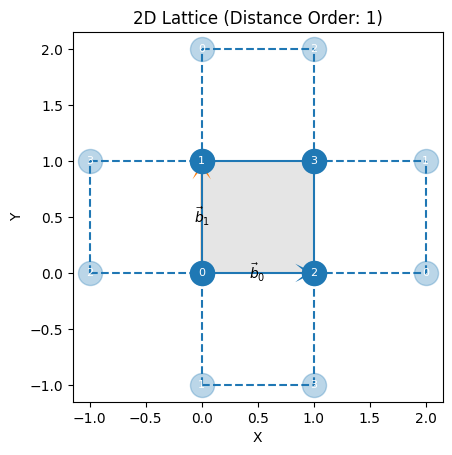

<Axes: title={'center': '2D Lattice (Distance Order: 1)'}, xlabel='X', ylabel='Y'>

In [8]:
g.draw()

In [9]:
ham = nkx.operator.FermiHubbardJax(hi, t=t_coefficient, U=U_coefficient, graph=g)
disj_graph = nk.graph.disjoint_union(g, g)
sa = nk.sampler.MetropolisFermionHop(hi, graph=g, n_chains=16, sweep_size=64)
# or let netket copy the graph per spin sector
sa = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, sweep_size=64, spin_symmetric=True
)


In [11]:
ma = nk.models.RBM(alpha=1, param_dtype=complex, use_visible_bias=False)
vs = nk.vqs.MCState(sa, ma, n_discard_per_chain=10, n_samples=512)

# we will use sgd with Stochastic Reconfiguration
opt = nk.optimizer.Sgd(learning_rate=0.01)
sr = nk.optimizer.SR(diag_shift=0.1, holomorphic=True)

gs = nk.driver.VMC(ham, opt, variational_state=vs, preconditioner=sr)

# now run the optimization
# first step will take longer in order to compile
exp_name = "2*2_fermions_test"
gs.run(500, out=exp_name)


100%|██████████| 500/500 [00:22<00:00, 22.06it/s, Energy=-3.158+0.002j ± 0.012 [σ²=0.072, R̂=1.0140]]    


(JsonLog('2*2_fermions_test', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.09186005592346191
   	Params: 0.09197449684143066,)

In [12]:
ma = nk.models.RBM(alpha=2, param_dtype=complex, use_visible_bias=False)
vs = nk.vqs.MCState(sa, ma, n_discard_per_chain=10, n_samples=512)
gs = nk.driver.VMC(ham, opt, variational_state=vs, preconditioner=sr)

# now run the optimization
# first step will take longer in order to compile
exp_name = "2*2_fermions_test_2"
gs.run(500, out=exp_name)

100%|██████████| 500/500 [00:36<00:00, 13.54it/s, Energy=-3.209+0.001j ± 0.013 [σ²=0.088, R̂=1.0096]]    


(JsonLog('2*2_fermions_test_2', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.12923192977905273
   	Params: 0.12846589088439941,)

In [ ]:
ma = nk.models.RBM(alpha=3, param_dtype=complex, use_visible_bias=False)
vs = nk.vqs.MCState(sa, ma, n_discard_per_chain=10, n_samples=512)
gs = nk.driver.VMC(ham, opt, variational_state=vs, preconditioner=sr)

# now run the optimization
# first step will take longer in order to compile
exp_name = "2*2_fermions_test_3"
gs.run(500, out=exp_name)

100%|██████████| 500/500 [02:31<00:00,  3.30it/s, Energy=-16.718-0.006j ± 0.032 [σ²=0.526, R̂=1.0121]]


(JsonLog('fermions_test_3', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.26499223709106445
   	Params: 0.18944406509399414,)

In [13]:
ma = nk.models.RBMModPhase(alpha=2, param_dtype=complex)
vs = nk.vqs.MCState(sa, ma, n_discard_per_chain=10, n_samples=512)
gs = nk.driver.VMC(ham, opt, variational_state=vs, preconditioner=sr)

# now run the optimization
# first step will take longer in order to compile
exp_name = "2*2_RBM_mod_phase_alpha2"
gs.run(500, out=exp_name)

100%|██████████| 500/500 [00:59<00:00,  8.47it/s, Energy=-3.219-0.000j ± 0.010 [σ²=0.052, R̂=1.0118]]    


(JsonLog('2*2_RBM_mod_phase_alpha2', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.20823931694030762
   	Params: 0.17114567756652832,)

In [14]:
ma = nk.models.RBMModPhase(alpha=3, param_dtype=complex)
vs = nk.vqs.MCState(sa, ma, n_discard_per_chain=10, n_samples=512)
gs = nk.driver.VMC(ham, opt, variational_state=vs, preconditioner=sr)

# now run the optimization
# first step will take longer in order to compile
exp_name = "2*2_RBM_mod_phase_alpha3"
gs.run(500, out=exp_name)

100%|██████████| 500/500 [01:16<00:00,  6.55it/s, Energy=-3.228+0.000j ± 0.013 [σ²=0.086, R̂=1.0085]]    


(JsonLog('2*2_RBM_mod_phase_alpha3', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.23282909393310547
   	Params: 0.19895291328430176,)

In [ ]:
ed_energies = np.linalg.eigvalsh(ham.to_dense())

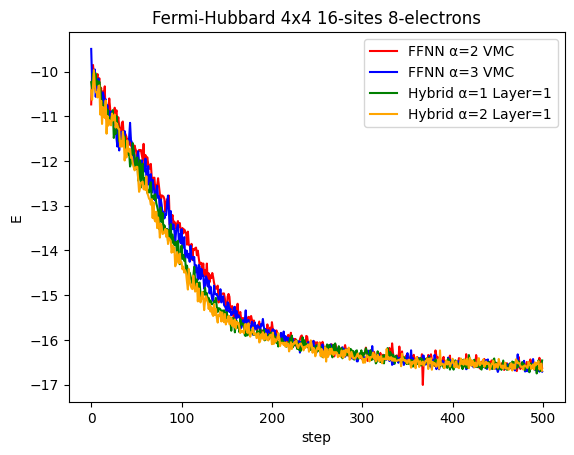

In [ ]:
############## plot #################


exp_name = "2*2_fermions_test"
with open(f"2*2_fermions_test.log") as f:
    data1 = json.load(f)
    
with open(f"2*2_fermions_test_2.log") as f:
    data2 = json.load(f)
    
with open(f"2*2_RBM_mod_phase_alpha2.log") as f:
    data3 = json.load(f)
    
with open(f"2*2_RBM_mod_phase_alpha3.log") as f:
    data4 = json.load(f)

x = data1["Energy"]["iters"]
y1 = data1["Energy"]["Mean"]["real"]
y2 = data2["Energy"]["Mean"]["real"]
y3 = data3["Energy"]["Mean"]["real"]
y4 = data4["Energy"]["Mean"]["real"]



# plot the energy levels
# plt.axhline(ed_energies[0], color="red", label="E0")
plt.title('Fermi-Hubbard 4x4 16-sites 8-electrons')
plt.plot(x, y1, color="red", label="FFNN α=2 VMC")
plt.plot(x, y2, color="blue", label="FFNN α=3 VMC")
plt.plot(x, y3, color="green", label="Hybrid α=1 Layer=1")
plt.plot(x, y4, color="orange", label="Hybrid α=2 Layer=1")

plt.legend()
plt.xlabel("step")
plt.ylabel("E")
plt.show()

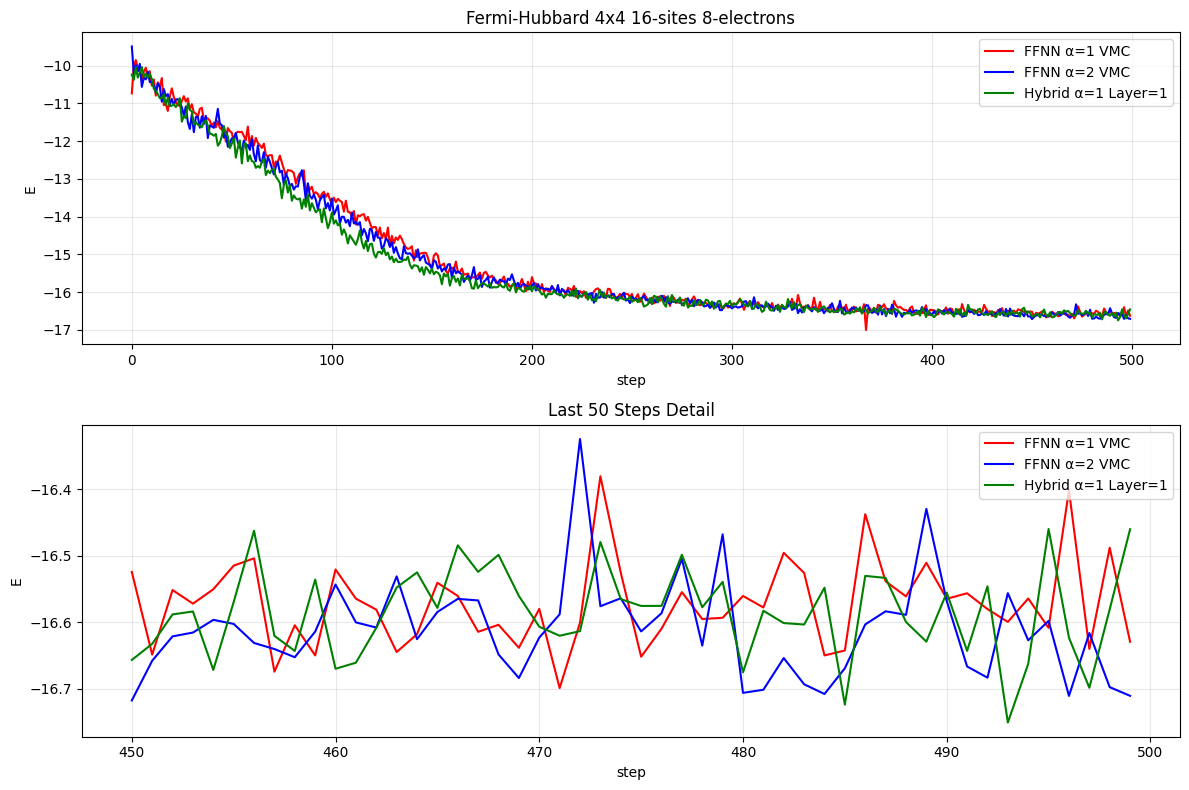

In [26]:
import matplotlib.pyplot as plt
import json
import numpy as np

exp_name = "fermions_test"
with open(f"fermions_test.log") as f:
    data1 = json.load(f)
    
with open(f"fermions_test_2.log") as f:
    data2 = json.load(f)
    
with open(f"RBM_mod_phase_alpha2.log") as f:
    data3 = json.load(f)

x = data1["Energy"]["iters"]
y1 = data1["Energy"]["Mean"]["real"]
y2 = data2["Energy"]["Mean"]["real"]
y3 = data3["Energy"]["Mean"]["real"]

# 创建图形和子图布局
fig = plt.figure(figsize=(12, 8))

# 主图
ax_main = plt.subplot(2, 1, 1)  # 2行1列，第1个位置
plt.title('Fermi-Hubbard 4x4 16-sites 8-electrons')
plt.plot(x, y1, color="red", label="FFNN α=1 VMC")
plt.plot(x, y2, color="blue", label="FFNN α=2 VMC")
plt.plot(x, y3, color="green", label="Hybrid α=1 Layer=1")
plt.legend(loc='upper right')
plt.xlabel("step")
plt.ylabel("E")
plt.grid(True, alpha=0.3)

# 子图 - 最后50轮的细节
ax_inset = plt.subplot(2, 1, 2)  # 2行1列，第2个位置
plt.title('Last 50 Steps Detail')

# 获取最后50个数据点
if len(x) >= 50:
    start_idx = len(x) - 50
else:
    start_idx = 0
    
x_last = x[start_idx:]
y1_last = y1[start_idx:]
y2_last = y2[start_idx:]
y3_last = y3[start_idx:]

plt.plot(x_last, y1_last, color="red", label="FFNN α=1 VMC")
plt.plot(x_last, y2_last, color="blue", label="FFNN α=2 VMC")
plt.plot(x_last, y3_last, color="green", label="Hybrid α=1 Layer=1")
plt.legend(loc='upper right')
plt.xlabel("step")
plt.ylabel("E")
plt.grid(True, alpha=0.3)

# 调整子图间距
plt.tight_layout()
plt.show()